# 랭그래프로 간단한 챗봇 만들기

## 필요 라이브러리 설치

In [1]:
%pip install langgraph

Note: you may need to restart the kernel to use updated packages.


## GPT 모델 설정

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_openai import ChatOpenAI

# 모델 초기화
model = ChatOpenAI(model="gpt-4o-mini")
model.invoke('안녕하세요!')

c:\anaconda\envs\LLM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_50906f2aac', 'id': 'chatcmpl-CiAMW5q8hlXPiXX6Dkj4aPk8noCzt', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--b613d259-d28e-4c87-a3ce-625163d057e1-0', usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

## 상태 정의
- `Annotated[T, func]`: 타입 T에 메타데이터나 동작을 추가할 때 사용
- `add_messages`: LangGraph가 제공하는 Reducer로 기존 메시지 리스트를 덮어쓰지않고 새로운 메시지를 리스트 뒤에 추가
  - `Reducer`? 함수형 프로그래밍에서 온 개념으로 기존 값과 새 값을 어떻게 합칠 것인가를 정의하는 함수

In [4]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
       'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]



## 그래프 정의
- StateGraph를 생성할 때 상태의 스키마로 State 전달
- 그래프가 처리할 데이터의 형태를 정의

In [5]:
graph_builder = StateGraph(State)

## 챗봇 노드 함수 정의

In [6]:
def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
		
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """ 
    return {"messages": [model.invoke(state["messages"])]}


graph_builder.add_node("generate", generate) # 그래프에 노드 추가

## 엣지 정의 및 컴파일

In [7]:
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)    

graph = graph_builder.compile()

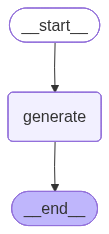

In [8]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception: 
    pass

## 그래프 실행
- 응답 메시지 : {'messages': [HumanMessage(...), AIMessage(...)]}

In [9]:
response = graph.invoke({"messages": ["안녕하세요! 저는 김정은입니다"]})

print(type(response))
response

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요! 저는 김정은입니다', additional_kwargs={}, response_metadata={}, id='24f58a91-f81c-4ac6-8c6f-3f303dcc458b'),
  AIMessage(content='안녕하세요, 김정은님! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 15, 'total_tokens': 30, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_50906f2aac', 'id': 'chatcmpl-CiAMjl9S0U0g3YYuMFv5WatmegOPu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--6b785693-e9a8-4ea7-8708-84e1532fcd55-0', usage_metadata={'input_tokens': 15, 'output_tokens': 15, 'total_tokens': 30, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]

In [10]:
response["messages"].append("제 이름을 아시나요?")
graph.invoke(response)

{'messages': [HumanMessage(content='안녕하세요! 저는 김정은입니다', additional_kwargs={}, response_metadata={}, id='24f58a91-f81c-4ac6-8c6f-3f303dcc458b'),
  AIMessage(content='안녕하세요, 김정은님! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 15, 'total_tokens': 30, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_50906f2aac', 'id': 'chatcmpl-CiAMjl9S0U0g3YYuMFv5WatmegOPu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--6b785693-e9a8-4ea7-8708-84e1532fcd55-0', usage_metadata={'input_tokens': 15, 'output_tokens': 15, 'total_tokens': 30, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),

## 스트리밍 출력

In [11]:
inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려줘")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

한국과 일본의 관계는 역사적으로 복잡하고 여러 차원에서 이루어져 있습니다. 두 나라 간의 관계는 정치, 경제, 문화 등 여러 분야에서 영향을 미치고 있으며, 이러한 관계는 과거의 역사적 사건들로 인해 복잡하게 얽혀 있습니다.

### 역사적 배경
1. **고대에서 근대까지**: 한국과 일본은 고대부터 교류를 해왔지만, 20세기 초 일제 강점기에 이르러 관계는 급격히 악화되었습니다. 1910년부터 1945년까지 일본은 한국을 식민지로 지배하였고, 이 기간 동안 많은 강제 동원, 문화 말살, 그리고 인권 유린이 발생했습니다.

2. **제2차 세계대전 이후**: 1945년 일본의 패전 이후, 한국은 분단되었고, 일본은 전후 처리를 위해 다양한 조치를 취해야 했습니다. 한국과 일본은 1965년에 한일 국교 normalization (정상화) 조약을 체결하여 공식적인 외교 관계를 맺게 되었습니다.

### 정치적 갈등
한국과 일본 간의 정치적 갈등은 주로 다음과 같은 문제로 인해 지속되고 있습니다:
- **역사 인식**: 일본의 역사 교과서에 대한 논란, 식민지 시대의 강제 징용과 위안부 문제 등 역사적 사건에 대한 시각 차이로 갈등이 발생하고 있습니다.
- **영토 분쟁**: 독도(일본에서는 다케시마로 불림)를 둘러싼 영토 분쟁도 양국 간의 갈등 요소 중 하나입니다.

### 경제적 관계
- **무역 및 투자**: 한국과 일본은 서로의 중요한 무역 파트너이며, 많은 기업들이 양국 간의 경제적 협력을 통해 성장하고 있습니다. 하지만, 최근 몇 년간 정치적 갈등으로 인해 무역 갈등이 발생하기도 하였습니다.
- **기술 협력**: 일본은 한국의 반도체, 자동차 등의 산업에 필요한 기술 및 부품의 공급국으로 중요한 역할을 하고 있습니다.

### 문화 교류
양국은 문화적으로도 서로에 대한 관심이 높습니다. K-Pop, 드라마, 영화와 같은 한국의 문화 콘텐츠는 일본에서 큰 인기를 얻고 있으며, 일본의 애니메이션, 만화, 패션 등도 한국에서 많은 사랑을 받고 있습니다. 이러